In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Custom functions
import FockSystem.FockSystem as fst

In [3]:
c_down = fst.OperSequence(0)
c_up = fst.OperSequence(2)
a_down = ~c_down
a_up = ~c_up

In [4]:
import Analysis.transport_tools as tu
from Analysis.systems import kitaev_chain, kramers_chain
import ultraplot as pplt

In [48]:
lead_params = {"gammas": [0.001]*4, "kBT": 0.003, "dV": 0.003}
bias_range = np.linspace(-80e-3,80e-3, 100)
mu_range = np.linspace(-100e-3,100e-3,100)

In [49]:

MU,ECT,CAR = kitaev_chain(3)
MU+= (c_down>>3)*(~(c_down>>3))
ECT += (c_down>>1)*((~c_down)>>3)
CAR -= (a_down>>1)*(a_down>>3)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:19<00:00,  5.20it/s]


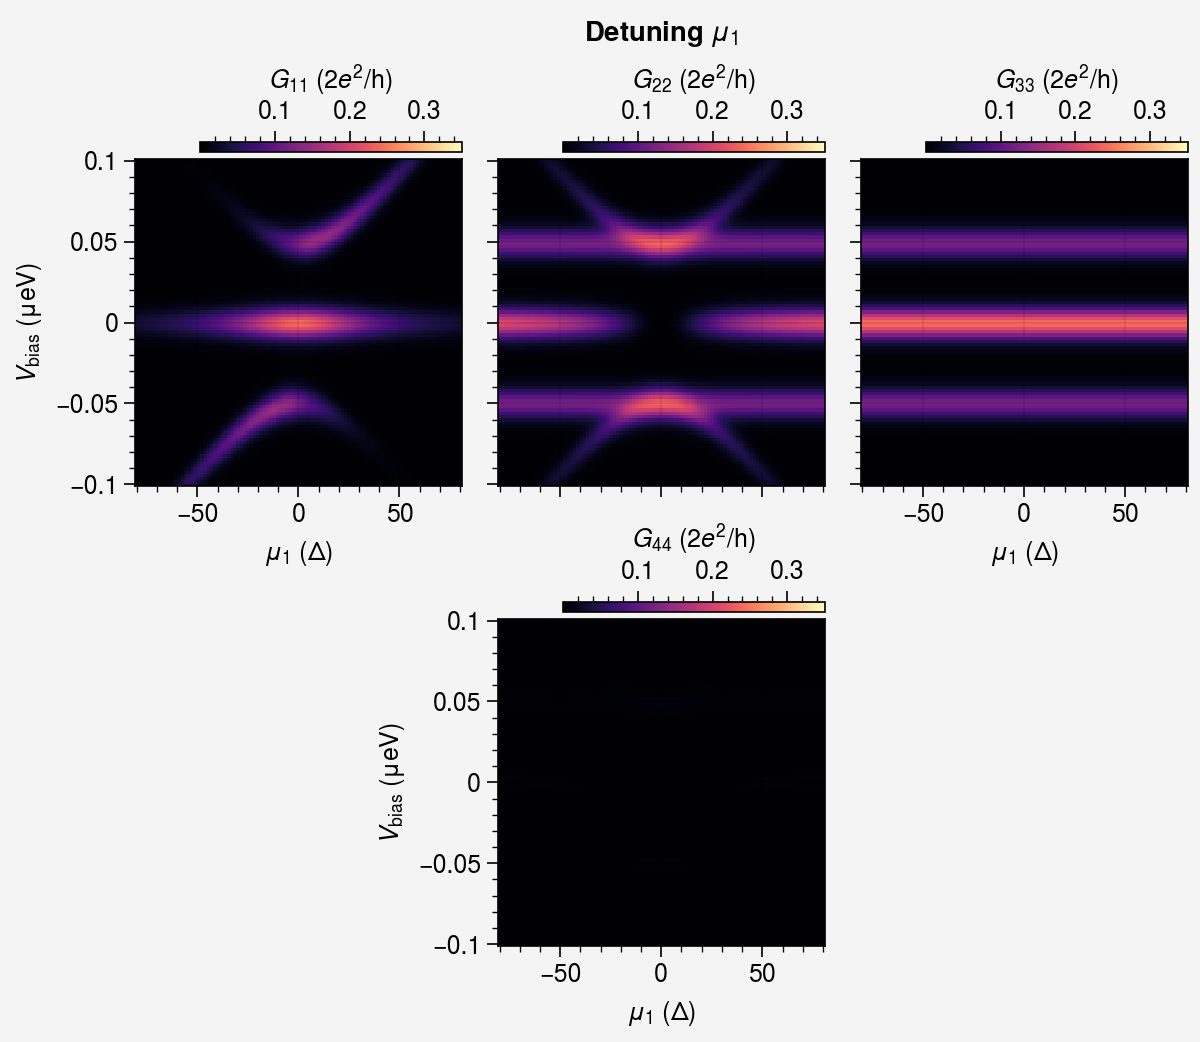

In [59]:
label = ['$\\mu_1$ ($\\Delta$)']
for idx,var in enumerate([MU[0]]):
    N=3
    MU,ECT,CAR = kitaev_chain(N)
    MU+= (c_down>>3)*(~(c_down>>3))
    ECT += (c_down>>1)*((~c_down)>>3)
    CAR -= (a_down>>1)*(a_down>>3)
    
    H = MU + CAR +ECT
    basis = fst.FockStates(N+1)
    inf_ez_basis = basis.restrict(Ez_inf=True,U_inf=True)
    #even_basis = basis.restrict('even',Ez_inf=True,U_inf=True)
    #odd_basis = basis.restrict('odd',Ez_inf=True,U_inf=True)
    
    H[CAR] = 20e-3
    H[ECT] = 20e-3
    H[MU] = 0
    H[CAR[2]] = 20e-3*np.exp(-1j*np.pi/2)
    H[MU[3]] = 200e-3
    
    Gs = tu.conductance_spectrum(H,inf_ez_basis,var, mu_range, bias_range,sites = np.arange(N+1), lead_params = lead_params)
    
    fig, axs = pplt.subplots([[1,2,3],[0,4,0]],figwidth=6)
    fig.format(ylabel = '$V_{\\mathrm{bias}}$ ($\\mathrm{\\mu}$eV)', xlabel = label[idx])
    fig.format(suptitle ='Detuning '+label[idx][:7])
    for i in range(len(axs)):
        im = axs[i].pcolormesh(Gs['bias_0']*1000,Gs['param'], Gs[f'G_{i}{i}'],cmap='magma',vmax=0.35)
        cbar = axs[i].colorbar(im,location='top',width=0.05, length=0.8,align='right',pad=0,label='$G_{'+f'{i+1}{i+1}'+'}$ (2$e^2$/h)')
        #Gs[f'G_{i}{i}'].plot(ax =axs[i], cmap='magma')
    

In [63]:
x = np.linspace(-2,2)
theta= 0.3

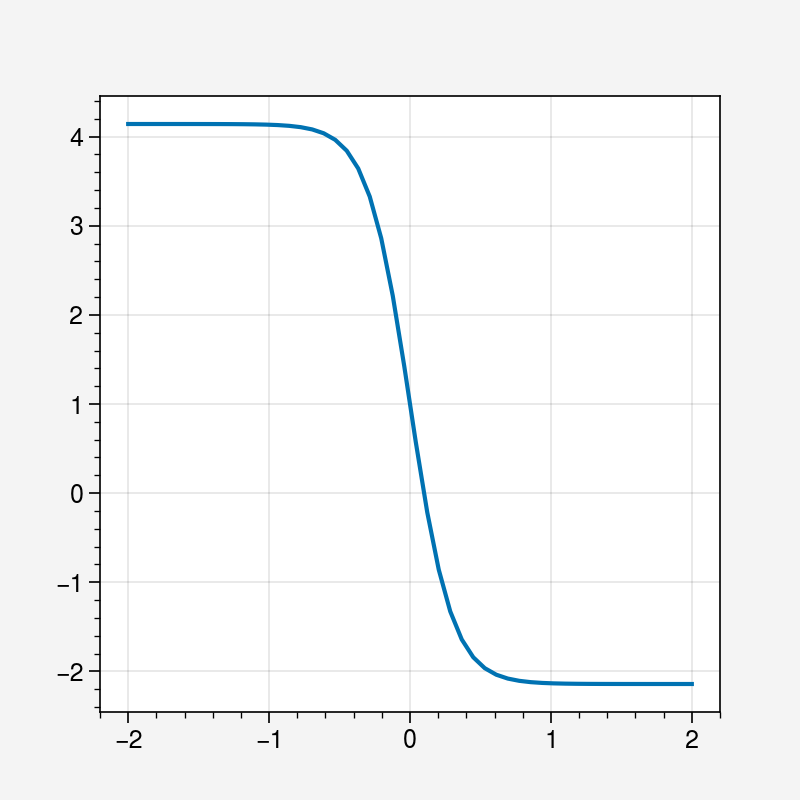

In [64]:
plt.plot(x,np.pi*(np.tanh(-x/theta))+1)